In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [103]:
df = pd.read_csv('online_shoppers_intention.csv')
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


<Axes: >

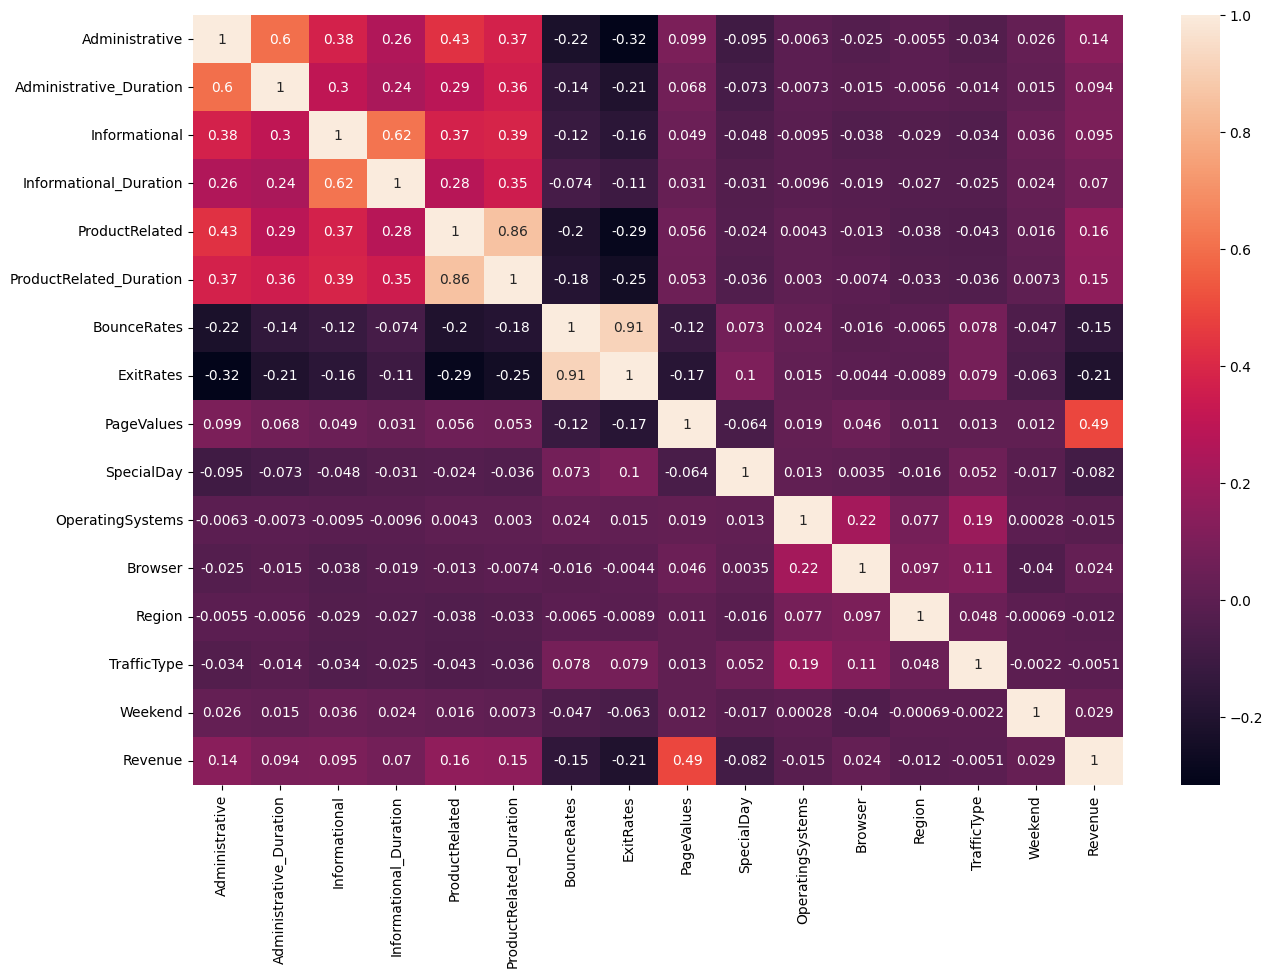

In [104]:
figsize(15,10)

sns.heatmap(df.corr(numeric_only = True), annot=True)

Итак, из корреляционной таблицы мы видим, каие признаки как влияют на целевую переменную (Revenue) и друг на друга. Интересным и значимым является отрицательное влияние на Revenue BounceRates и ExitRates. Также можно заметить, что довольно высокая положительная корреляция у признаков, имющих отрицательную корреляцию с признаками "ухода" - ProductRelated и ProductRelated_Duration. Основываясь на этом, можно рассмотреть, как поведение пользователя во время сессии влияет на то, совершит он покупку на сайте или нет. В этом направлении также стоит рассмотреть Administrative и Informational признаки, чтобы понять как страницы с административной и технической информацией и то, сколько времени пользователь на них проводит, влияют на покупку.

<Axes: >

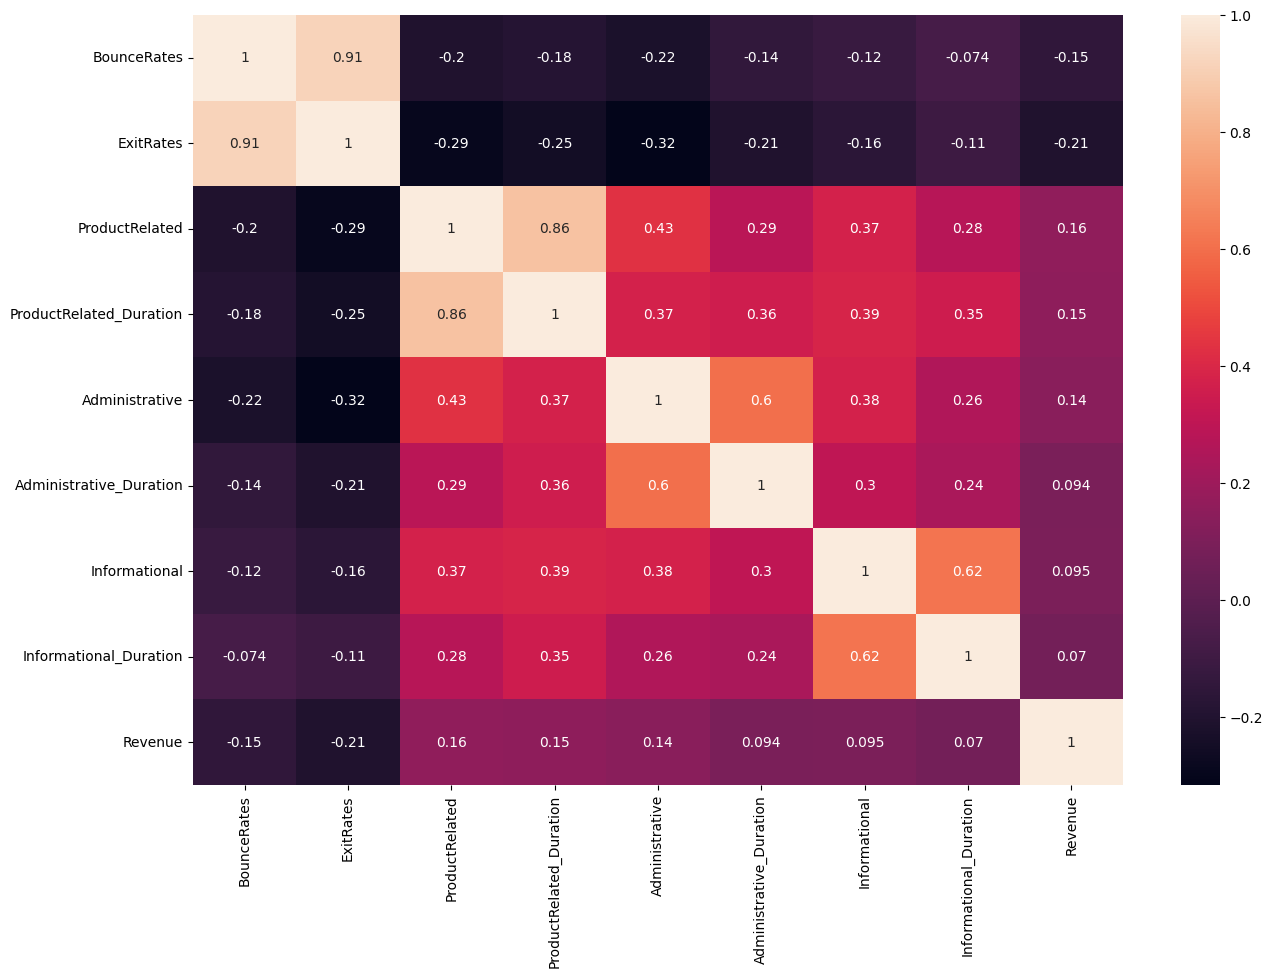

In [105]:
sns.heatmap(df[['BounceRates',
        'ExitRates',
        'ProductRelated',
        'ProductRelated_Duration',
        'Administrative',
        'Administrative_Duration',
        'Informational',
        'Informational_Duration',
        'Revenue']].corr(numeric_only=True),annot=True)

In [106]:
df1 = df[['BounceRates',
        'ExitRates',
        'ProductRelated',
        'ProductRelated_Duration',
        'Administrative',
        'Administrative_Duration',
        'Informational',
        'Informational_Duration',
        'Revenue']]

Посмотрим, как в целом отличаются показатели пользователей, совершивших покупку и не совершивших. Для этого разделим их на группы покупателей и не покупателей.

In [107]:
buyers = df1[df1['Revenue']==True]
not_buyers = df1[df1['Revenue']==False]

In [108]:
buyers.describe()

,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration,Administrative,Administrative_Duration,Informational,Informational_Duration
count,1908.000000,1908.000000,1908.000000,1908.000000,1908.000000,1908.000000,1908.000000,1908.000000
mean,0.005117,0.019555,48.210168,1876.209615,3.393606,119.483244,0.786164,57.611427
std,0.012185,0.016463,58.267365,2312.214392,3.730527,201.114732,1.521176,171.619131
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.009521,15.000000,541.906250,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.016000,29.000000,1109.906250,2.000000,52.366667,0.000000,0.000000
75%,0.006452,0.025000,57.000000,2266.011310,5.000000,151.083333,1.000000,19.000000
max,0.200000,0.200000,534.000000,27009.859430,26.000000,2086.750000,12.000000,1767.666667


In [109]:
not_buyers.describe()

,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration,Administrative,Administrative_Duration,Informational,Informational_Duration
count,10422.000000,10422.000000,10422.000000,10422.000000,10422.000000,10422.000000,10422.000000,10422.000000
mean,0.025317,0.047378,28.714642,1069.987809,2.117732,73.740111,0.451833,30.236237
std,0.051877,0.051231,40.744717,1803.797757,3.202481,171.017970,1.211582,133.909306
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.015560,6.000000,151.000000,0.000000,0.000000,0.000000,0.000000
50%,0.004255,0.028571,16.000000,510.190000,0.000000,0.000000,0.000000,0.000000
75%,0.020000,0.053846,35.000000,1331.816667,3.000000,83.000000,0.000000,0.000000
max,0.200000,0.200000,705.000000,63973.522230,27.000000,3398.750000,24.000000,2549.375000


Из описания двух получившихся датасетов видим, что BounceRates и ExitRates у покупателей значительно ниже, чем у не покупателей. Это может значить, что пользователи, совершившие покупку гораздо реже покидают сайт без значимых взаимодействий (медиана примерно 0), чем пользователи не совершившие покупку. И в целом реже склонны быстро заканчивать сессию.

Также можно заметить, что покупатели гораздо более активно взаимодействуют с товарными страницами - ProductRelated медиана у покупателей 29, против 16 у не покупателей; а медианное время взаимодействия с продуктовыми страницами отличается на практически 600 в пользу покупателей.

Также мы можем заметить, что пользователи, совершающие покупку, чаще взаимодействую с административными страницами сайта (вероятно, регистрируются и т.д.) - у не покупателей медианные значения Adminisrative и Administrative_duration 2 и 52 у покупателей, против 0 у не покупателей.

Взаимодействие с информационными страницами медианное у покупателей и не покупателей 0, но у покупателей среднее  все же выше.

Интересно заметить, что максимальные значения во взаимодействиях с административными и информационными страницами у не покупателей выше. Может, пользователь так и не смог разобраться в работе сайта, долго мучился и ушел.

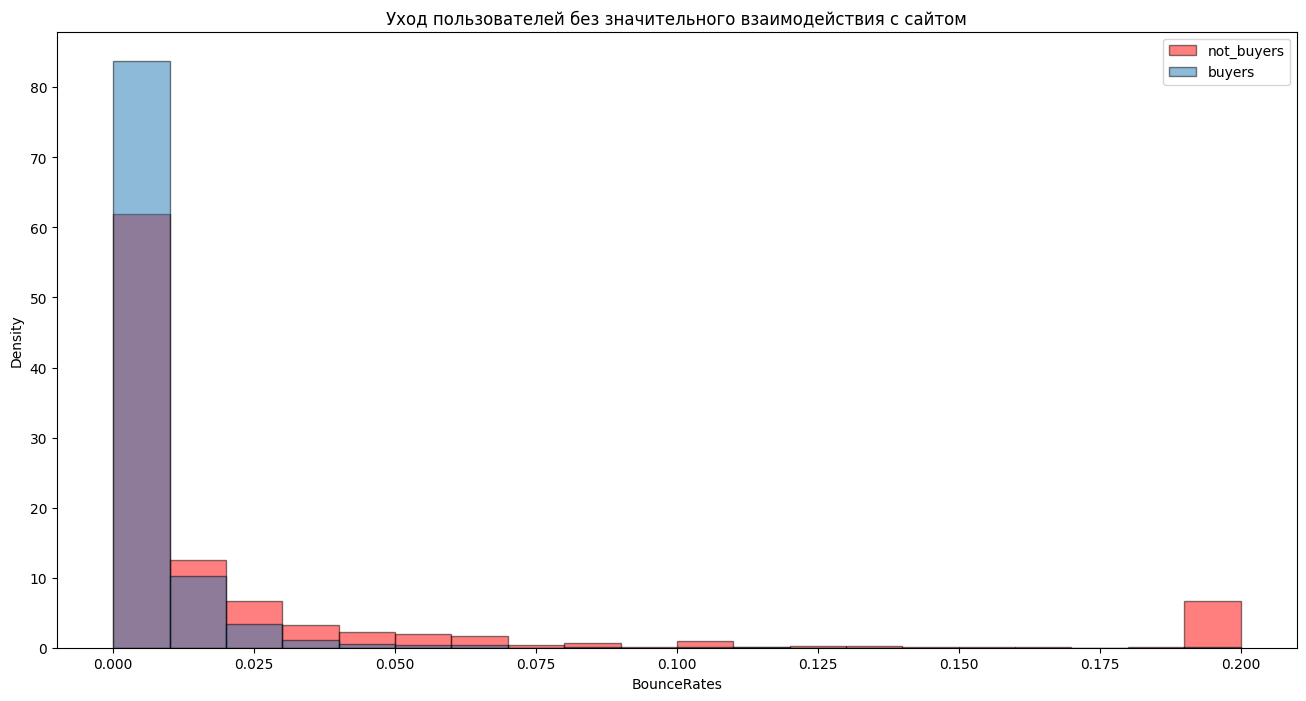

In [110]:
figsize(16, 8)

plt.hist(not_buyers['BounceRates'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['BounceRates'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('BounceRates')
plt.ylabel('Density')
plt.title('Уход пользователей без значительного взаимодействия с сайтом')
plt.legend()

(т.к. не покупателей по количеству у нас значительно больше, то в графиках будем использовать относительные показатели)

Из графика видим, что большинство покупателей имеют очень низкий BounceRates. У пользователей не совершивших покупку распределение имеет большой разброс значений и есть высокие значения BounceRates. Это свидетельствует о том, что пользователи совершившие покупку, очень редко покидают сайт без значительных взаимодействий. Пользователи же не совершившие покупку, также довольно часто совершают какие-то значительные взаимодействия перед тем, как покинуть сайт, но также периодически их количество сильно меньше, чем у покупателей.

Также можно отметить, что данные имеют выбросы и распределены ненормально.

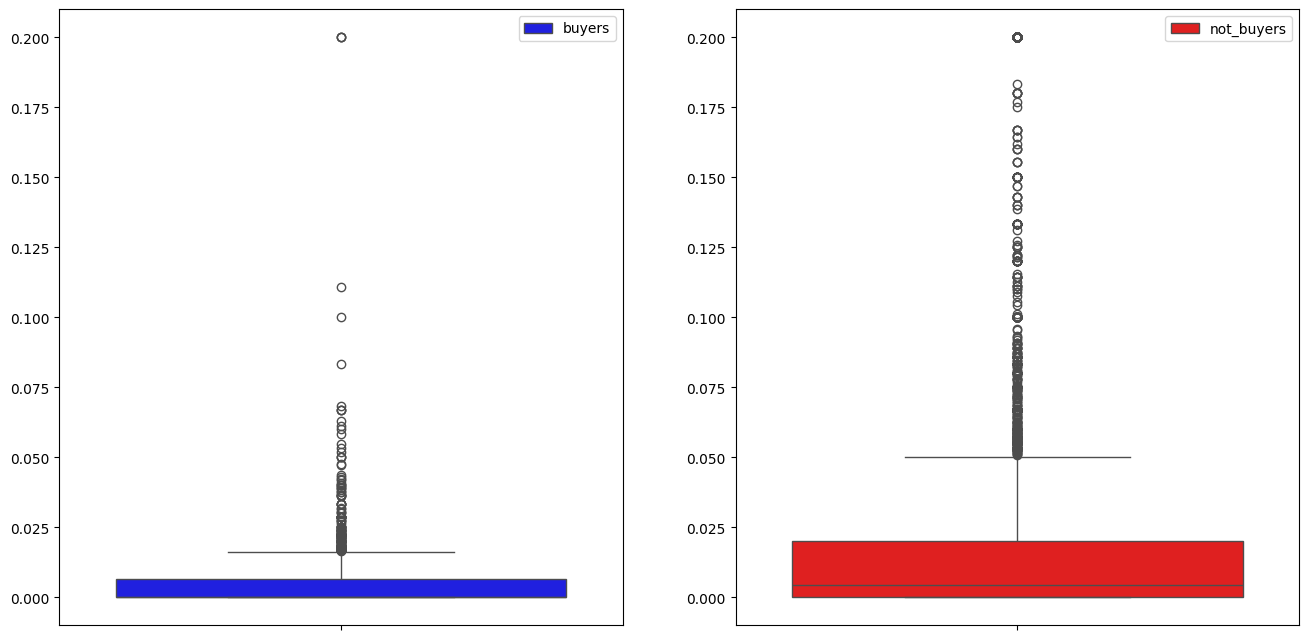

In [111]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['BounceRates'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['BounceRates'].values, color = 'red', label='not_buyers')
plt.legend()

BoxPlot еще раз показал, что в данных присутствуют значительные выбросы, а также то, что не покупатели чаще уходят с сайтов без значительного взаимодействия, тогда как медианные значения этого показателя у покупателей близки к 0.

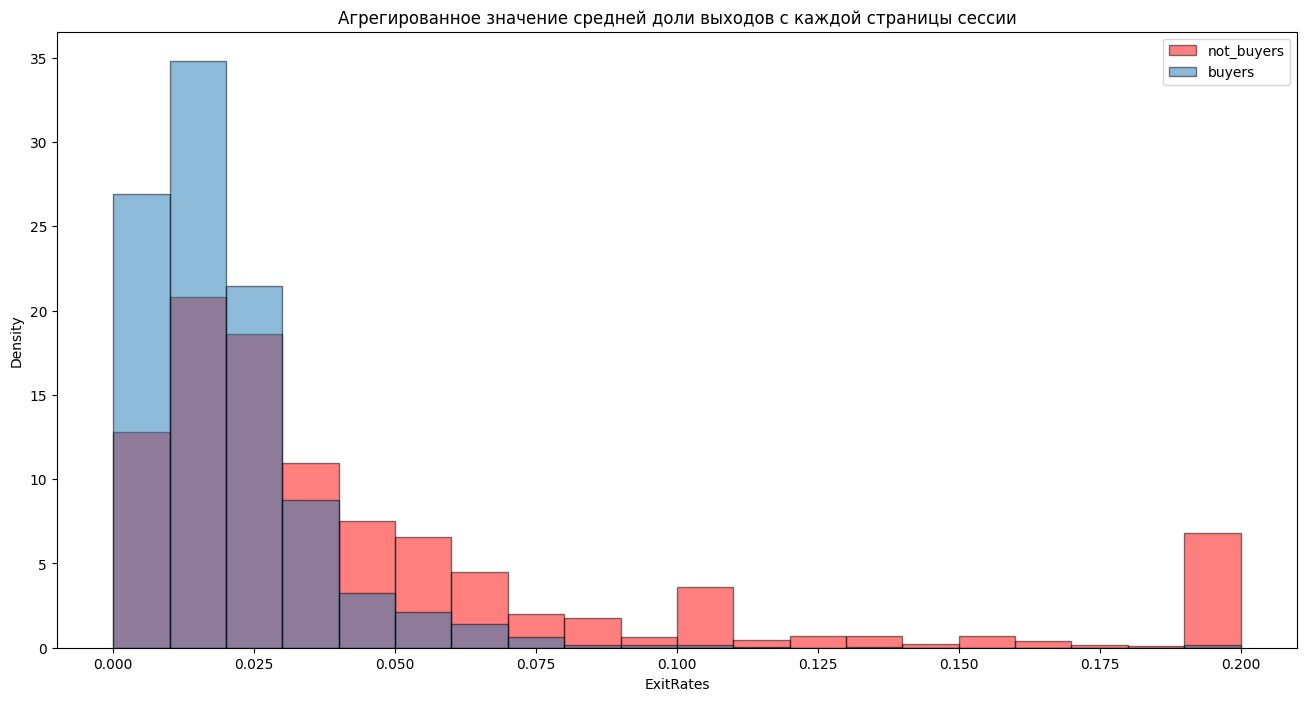

In [112]:
figsize(16, 8)

plt.hist(not_buyers['ExitRates'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['ExitRates'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('ExitRates')
plt.ylabel('Density')
plt.title('Агрегированное значение средней доли выходов с каждой страницы сессии')
plt.legend()

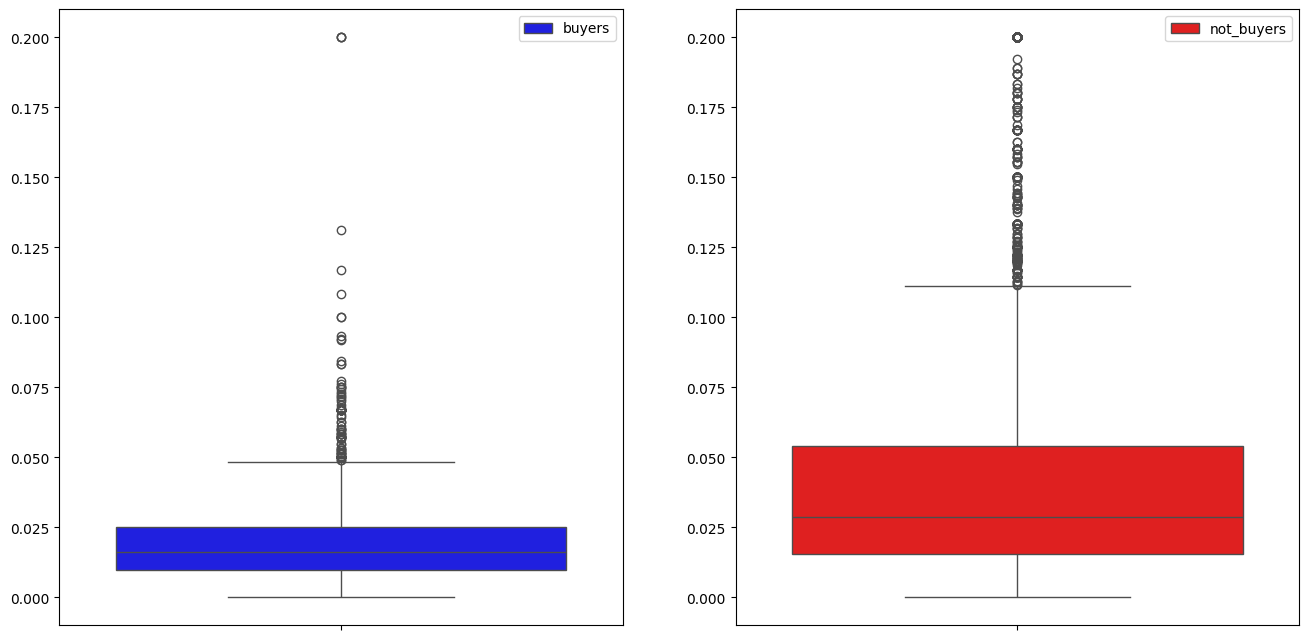

In [113]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['ExitRates'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['ExitRates'].values, color = 'red', label='not_buyers')
plt.legend()

Аналогично у покупателей значение ExitRates в среднем ниже и сосредоточено вблизи нуля, тогда как у респределения не покупателей правый хвост присутствует. Это может свидетельствовать о том, что пользователи, совершившие покупку, реже просматривают страницы с высокой вероятностью завершения сессии. С другой стороны, пользователи без покупки чаще взаимодействуют со страницами, после посещения которых сессия чаще всего завершается.

На графиках также наблюдается выраженная ассиметрия и выбросы.

В отличие от BounceRates, значение ExitRates у покупателей чуть больше распределено вправо от нуля. Это, вероятно, потому что у многих страниц значение ExitRates > 0, так как какие-то пользователи да и завершали взаимодействие с сайтом после их посещения.

Посмотрим также как влияют друг на друга BounceRates и ExitRates.

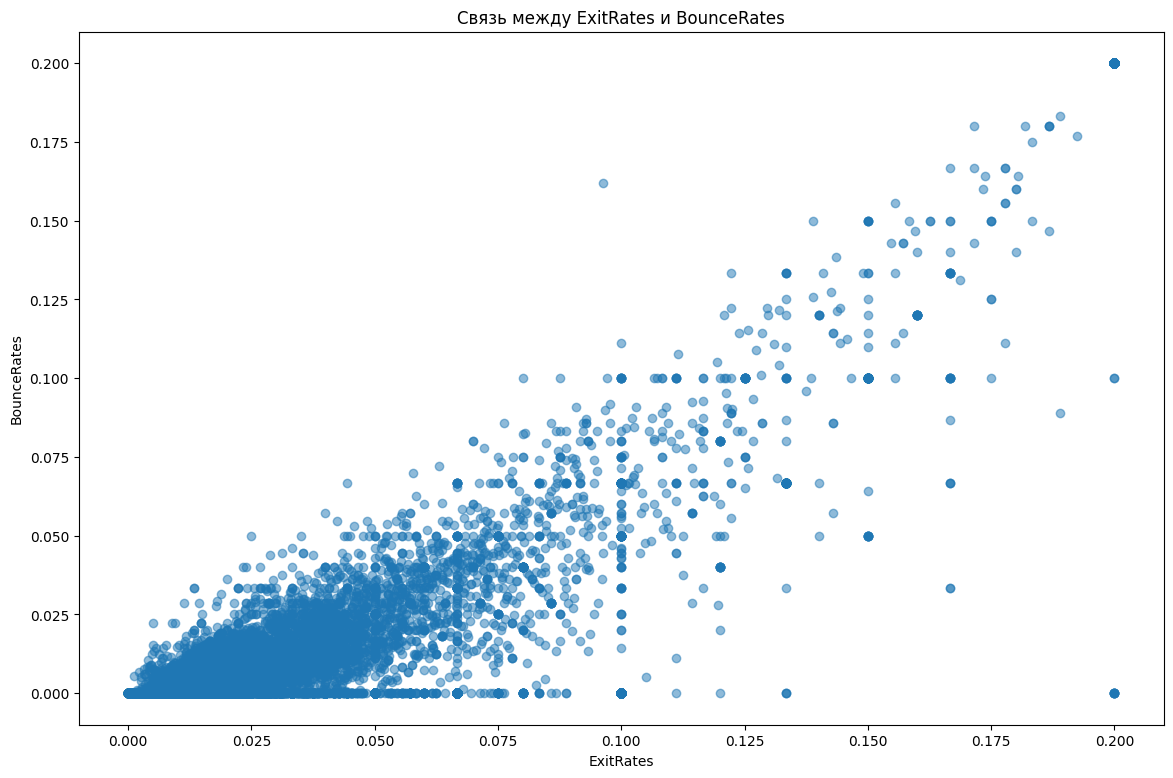

In [114]:
fig, ax = plt.subplots(figsize=(14,9))
color_graph = ax.scatter(df['ExitRates'],
                         df['BounceRates'],
                         alpha=0.5)
ax.set_xlabel('ExitRates')
ax.set_ylabel('BounceRates')

ax.set_title('Связь между ExitRates и BounceRates')

plt.show()

Итак, мы можем видеть практически линейную положительную зависимость ExitRates и BounceRates, что подтверждается также значением 0.91 в корреляционной матрице.

на корреляционной матрице видим, что ProductRelated_Duration имеет положительную корреляцию с Revenue, а PageValues вообще самую высокую среди всех признаков. выше мельком было замечено что покупатели активнее взаимодействуют с товарными страницами. рассмотрим как средняя ценность просматриваемых страниц и время на продуктовых страницах связаны с покупкой.

PageValues это средняя ценность страниц, посещенных пользователем в сессии(метрика от Google Analytics)
ProductRelated_Duration – суммарное время(в секундах) на страницах с товарами

In [115]:
df2 = df[['PageValues', 'ProductRelated_Duration', 'Revenue']]
df2

,PageValues,ProductRelated_Duration,Revenue
0,0.000000,0.000000,False
1,0.000000,64.000000,False
2,0.000000,0.000000,False
3,0.000000,2.666667,False
4,0.000000,627.500000,False
...,...,...,...
12325,12.241717,1783.791667,False
12326,0.000000,465.750000,False
12327,0.000000,184.250000,False
12328,0.000000,346.000000,False


In [116]:
buyers = df2[df2['Revenue']==True]
not_buyers = df2[df2['Revenue']==False]

In [117]:
buyers.describe()

,PageValues,ProductRelated_Duration
count,1908.000000,1908.000000
mean,27.264518,1876.209615
std,35.191954,2312.214392
min,0.000000,0.000000
25%,3.641144,541.906250
50%,16.758134,1109.906250
75%,38.897742,2266.011310
max,361.763742,27009.859430


In [118]:
not_buyers.describe()

,PageValues,ProductRelated_Duration
count,10422.000000,10422.000000
mean,1.975998,1069.987809
std,9.072424,1803.797757
min,0.000000,0.000000
25%,0.000000,151.000000
50%,0.000000,510.190000
75%,0.000000,1331.816667
max,246.758590,63973.522230


по PageValues: у покупателей медиана равна 16,76, а у непокупателей вообще 0, причем даже 75 перцентиль у них ноль. то есть во время сесси покупатели заходили на страницы с реальной ценностью(по типу карточек с информацией о товаре, оформления заказа, корзины), а 75% из непокупателей вообще не добрались бедняжки до ценных страничек, просто как называется виндоу шоппинг делали(английский с1 ххахах), но онлайн. смотрели главную страницу или читали что то о компании просто. еще интересно, что у покупаталей достаточно большой разброс(станд отклонение 35), то есть получается, что одни быстро покупают, не гуляя по страницам, другие доолго ходят по сайтам и только потом уже покупают что то

по ProductRelated_Duration: и те и те проводят время на продуктовых страницах, но покупатели сильно больше(медиана 1110 секунд). прикол, что максимум у не покупателей 63973с. это какой то мега выюрос, наверно кто то открыл вкладку и забил

Text(0, 0.5, 'PageValues')

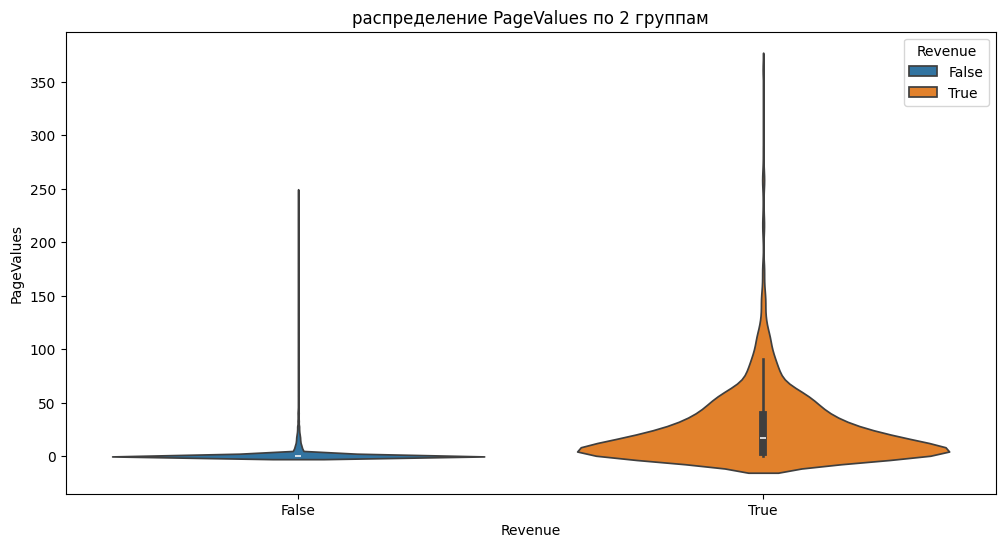

In [119]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Revenue', y='PageValues', data=df2, hue='Revenue')

plt.title('распределение PageValues по 2 группам')
plt.xlabel('Revenue')
plt.ylabel('PageValues')

ну все в принципе подтверждается. у непокупателей распределенияе расплюснута у нуля. у покупателей заметно шире в нижней части и медиана выше нуля, те значения PageValues реально выше

In [120]:
from scipy.stats import shapiro

In [121]:
shapiro(buyers['PageValues'])

ShapiroResult(statistic=np.float64(0.7110258606858566), pvalue=np.float64(2.6481700156825925e-49))

In [122]:
shapiro(not_buyers['PageValues'])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10422.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.2249004756092956), pvalue=np.float64(9.254585481359894e-110))

In [123]:
shapiro(buyers['ProductRelated_Duration'])

ShapiroResult(statistic=np.float64(0.675652083085072), pvalue=np.float64(3.326364458179571e-51))

In [124]:
shapiro(not_buyers['ProductRelated_Duration'])

ShapiroResult(statistic=np.float64(0.5226613931630133), pvalue=np.float64(1.4703382684169156e-97))

у всех pvalue почти ноль, то есть меньше 0,05, значит H0 гипотеза(распределение нормально) отвергается и не отвергается гипотеза H1(о ненормальности распределения)

и describe и violin plot показали одно и то же, PageValues у покупателей выше, а у непокупателей практически равен нулю. проверим статистически!

итак, отвественный момент, выдвигаем ГИПОТЕЗУ

H0: распределение PageValues у покупателей и не покупателей одинаково
H1: PageValues у покупателей статистически значимо выше

для поверки гипотезы был выбран критерий Манна-Уитни, он подходит для сравнения двух независимых групп =, не требует нормального распредления, которого у нас как раз не имеется

In [125]:
from scipy.stats import mannwhitneyu

In [126]:
stat, p_value = mannwhitneyu(buyers['PageValues'], not_buyers['PageValues'], alternative='greater')
print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 17166757.0, p-значение: 0.0


ну тут pvalue аж округлился до нуля, настолько маленькое значение, точно меньше 0,05. значит, отвергаем гипотезу H0 мега уверенно, то есть PageValues у покупателей выше, чем у непокупателей

нашему заказчику(а он тут с нами в одной комнате?) надо призадуматься, это еще при том, что 75% непокупателей до ценных страниц вообще не доходят. возможно проблема не в том, что пользователь видит товар и не покупает, а он просто не доходит до него. да, конечно стоит не забывать про то, что неопкупатель вообще может не хочет покупать совсем изначально, поэтмоу никуда нафиг не заходит. но в любом случае, полагаю, что улучшение навигации, системы рекомендаций и выгодных приложенийна сайте могло бы улучшить ситуацию и побольше людей подтолкнуть совершить покупку

далее переходим к ProductRelated_Duration, краем глаза видели, что у покупателей значение больше, но также весьма интересно посмотреть на то, как типы пользователей ведут себя на продуктовых страничках. новые и возвращающиеся пользователи это разные сегменты с разной мотивацией и уровнем готовности к покупке, поэтому следует подбирать к ним разные подходы

In [127]:
df2 = df[['PageValues', 'ProductRelated_Duration', 'VisitorType', 'Revenue']]
df2

,PageValues,ProductRelated_Duration,VisitorType,Revenue
0,0.000000,0.000000,Returning_Visitor,False
1,0.000000,64.000000,Returning_Visitor,False
2,0.000000,0.000000,Returning_Visitor,False
3,0.000000,2.666667,Returning_Visitor,False
4,0.000000,627.500000,Returning_Visitor,False
...,...,...,...,...
12325,12.241717,1783.791667,Returning_Visitor,False
12326,0.000000,465.750000,Returning_Visitor,False
12327,0.000000,184.250000,Returning_Visitor,False
12328,0.000000,346.000000,Returning_Visitor,False


In [128]:
df2.groupby('VisitorType')['ProductRelated_Duration'].median()

VisitorType
New_Visitor          414.250000
Other                136.500000
Returning_Visitor    655.542857
Name: ProductRelated_Duration, dtype: float64

In [129]:
median = df2.groupby('VisitorType')['ProductRelated_Duration'].median()

In [130]:
median

VisitorType
New_Visitor          414.250000
Other                136.500000
Returning_Visitor    655.542857
Name: ProductRelated_Duration, dtype: float64

Text(0, 0.5, 'ProductRelated_Duration(медиана)')

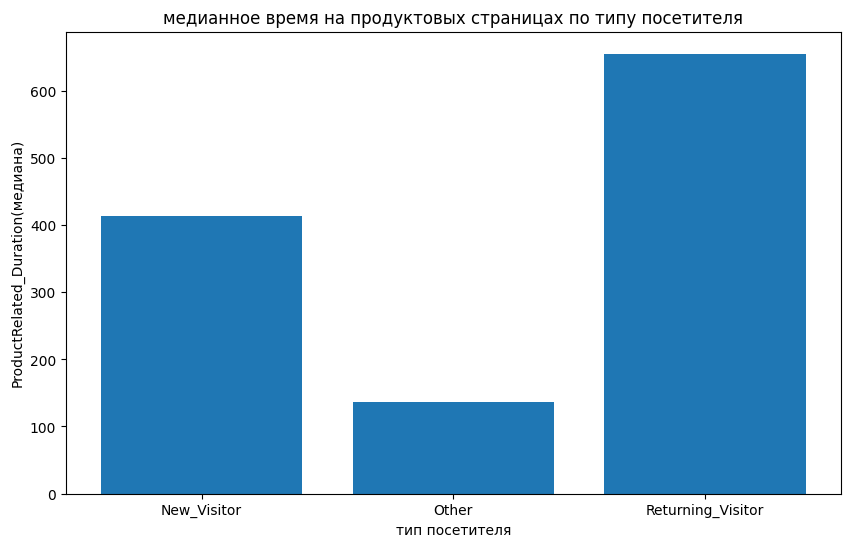

In [131]:
figsize(10, 6)
plt.bar(median.index, median.values)
plt.title('медианное время на продуктовых страницах по типу посетителя')
plt.xlabel('тип посетителя')
plt.ylabel('ProductRelated_Duration(медиана)')

Returning_Visitor проводит на продуктовых страницах больше времени, чем New_Visitor. хм, вообще это довольно интересные результаты. проверим значимо ли это различие!

other эт овообще непонятно кто – боты и всякое короче не супер нужное и значимое нам для анализа. поэтому не брала его дальше

итак, гипотеза 2!!!

H0: время на продуктовых страницах у New_Visitor и Returning_Visitor одинаково
H1: время на продуктовых страницах у Returning_Visitor больше чем у New_Visitor

тот же Манна-Уитни с таким же обоснованием

In [132]:
new = df2[df2['VisitorType'] == 'New_Visitor']['ProductRelated_Duration']
returning = df2[df2['VisitorType'] == 'Returning_Visitor']['ProductRelated_Duration']

In [133]:
stat, p_value = mannwhitneyu(returning, new, alternative='greater')
print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 10582331.0, p-значение: 1.839475578978149e-34


p-значение значительно меньше 0,05. значит отвергаем нулевую гипотезу, те Returning_Visitor проводит статистически значимо больше времени на продуктовых страницах чем New_Visitor

с учетом того, что мы еще проверяем гипотезы с конверсией по типу посетителя, будет интереснее и лучше сделать общий бизнес-вывод(следует далее..)

хочеца доп баллов, давайте проведем сранвительный анализ в рамках гипотезы 1. вычитала, что если выборка большая, то можно использовать t-тест Уэлча к нашим данным, тк он становится устойчив к ненормальности(че то там потому что по ЦПТ при больших размерах выборки стремимся к нормальному распределению). также тут https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html написано "This is a test for the null hypothesis that 2 independent samples have identical average (expected) values. This test assumes that the populations have identical variances by default." выборки у нас точно индепендет(покупатели/не покупатели), дисперсии разные, но можно прям достоверно проверить с помощью критерия Левена 

In [134]:
from scipy.stats import levene

In [135]:
levene(buyers['PageValues'], not_buyers['PageValues'])

LeveneResult(statistic=np.float64(3224.16055232711), pvalue=np.float64(0.0))

тут pvalue равен нулю, меньше 0,05, значит гипотеза H0(о равентсве дисперсий) отклоняется

In [136]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(buyers['PageValues'], not_buyers['PageValues'], equal_var=False, alternative='greater')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 31.199175198717576
P-value: 4.805334750001536e-174


тут правда получается, что тест Уэлча проверяет немножко под другим углом так сказать, и формально надо выдвинуть свои H0 и H1, хоть мы и делаем сравнение в контексте гипотезы 1(H0: распределение PageValues у покупателей и не покупателей одинаково
H1: PageValues у покупателей статистически значимо выше):

H0: средние PageValues у покупателей и непокупателей равны
H1: среднее PageValues у покупателей статистически значимо выше

p_value меньше 0,05, так что так же отвергаем гипотезу H0 как и в проверке с помощью Манна-Уитни. то есть оба теста подтверждают статистические значимые различия в показателях PageValues, а именно то, что PageValue выше у покупателей. различие между группами улавливается и через сравнение средних, и через сравнение распределений. так что нас вывод теперь точно надежен!

в контексте нашего анализа это означает, что вывод устойчив при использовании разных подходов. PageValues в принципе можно использовать как надежный индикатор того, собирается ли пользователь шо нибудь у нас приобрести. челик с высоким PageValues в сессии это наш потенциальный покупатель(конечно если аналитика так настроена, что можно рассчитывать и обновлять этот показатель в релаьном времени), и именно на таких стоит таргетировать персональные предложения и скидки в реальном времени